# 01 — The Data, The Confounding, and Why Naive Targeting Fails

This demo builds a causal uplift model for allocating promotional spend in an
accommodation-marketplace setting — heterogeneous treatment effect estimation
with neural attention + doubly-robust debiasing.

This first notebook does three things:
1. Generates a synthetic but realistic promotional-booking dataset with a
   **known ground-truth treatment effect** for every unit (only possible
   because it's simulated — real data never gives you this).
2. Shows that a naive treated-vs-control comparison is **biased**, because
   who gets shown a promo is not random (marketing already targets
   price-sensitive, mid-loyalty users more aggressively).
3. Shows that the treatment effect is **heterogeneous** — it varies by user,
   and some users are actively hurt by the promo (margin cannibalization on
   bookings that would have happened anyway).

Together these motivate the two things the Day 2 model has to do:
**debias** the confounded assignment, and **personalize** the effect
estimate per user.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from simulate import simulate_promo_data

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

df = simulate_promo_data(n=20_000, seed=42)
print(df.shape)
df.head()

(20000, 14)


,loyalty_tier,price_sensitivity,lead_time_days,past_bookings,device_mobile,length_of_stay,base_price,propensity_true,treatment,y0_true,y1_true,ite_true,y,quadrant
0,0,-1.883328,7.876155,0,1,4,74.630363,0.301048,1,26.897282,20.580453,-6.316829,20.580453,lost_cause
1,3,1.130478,3.610336,6,0,5,120.047210,0.611566,0,49.726580,56.495017,6.768437,49.726580,sure_thing
2,2,1.182725,10.750297,3,1,3,97.496461,0.804193,0,32.077320,63.935381,31.858062,32.077320,persuadable
3,1,-0.474367,24.321832,2,0,3,84.681344,0.456599,1,32.109605,26.217672,-5.891933,26.217672,lost_cause
4,1,0.521276,2.466388,2,1,3,153.350616,0.664913,1,40.379234,64.069082,23.689848,64.069082,persuadable


## 1. The confounding problem

Treatment assignment depends on covariates (price sensitivity, loyalty tier), so simply comparing average outcomes between treated and control units gives a biased estimate of the causal effect.

In [2]:
true_ate = df["ite_true"].mean()
naive_diff = df.loc[df.treatment == 1, "y"].mean() - df.loc[df.treatment == 0, "y"].mean()

print(f"True ATE (ground truth, only known because this is simulated): {true_ate:.3f}")
print(f"Naive treated-vs-control difference in means:                  {naive_diff:.3f}")
print(f"Relative bias of the naive estimate:                           {100*(naive_diff-true_ate)/true_ate:.1f}%")

True ATE (ground truth, only known because this is simulated): 3.173
Naive treated-vs-control difference in means:                  1.095
Relative bias of the naive estimate:                           -65.5%


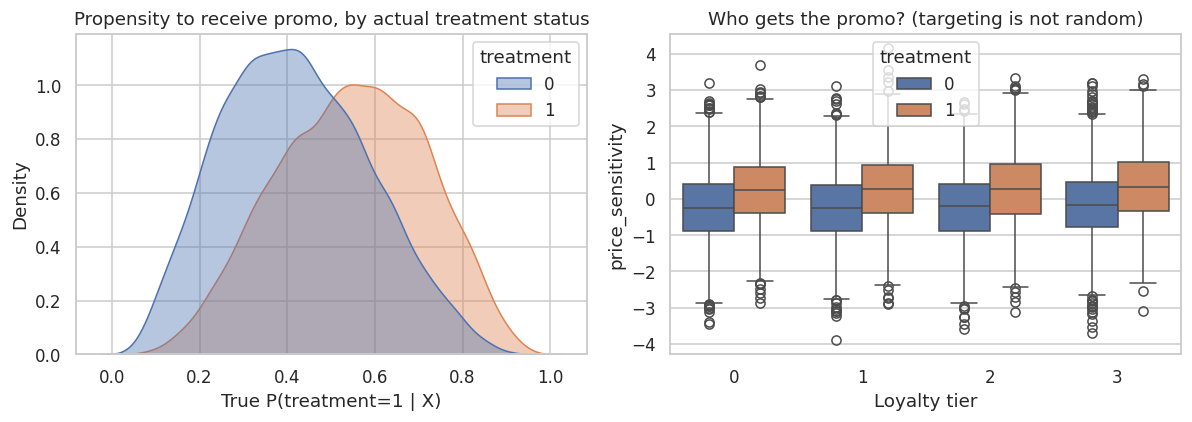

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.kdeplot(data=df, x="propensity_true", hue="treatment", fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title("Propensity to receive promo, by actual treatment status")
axes[0].set_xlabel("True P(treatment=1 | X)")

sns.boxplot(data=df, x="loyalty_tier", y="price_sensitivity", hue="treatment", ax=axes[1])
axes[1].set_title("Who gets the promo? (targeting is not random)")
axes[1].set_xlabel("Loyalty tier")

plt.tight_layout()
plt.savefig("../figures/01_confounding.png", bbox_inches="tight")
plt.show()

There's good overlap between treated and control across the propensity range (no region has *zero* chance of either treatment status), which is what makes IPW-style correction valid here — in a real deployment this is exactly the diagnostic you'd run before trusting any debiasing method.

The right panel shows the actual targeting pattern: mid-tier, price-sensitive users are shown the promo far more often than top-tier, price-insensitive users. That's the source of the bias above.

## 2. Heterogeneous treatment effects — the four uplift quadrants

A single average effect hides more than it reveals. The business-relevant
question is *who* the promo actually changes behavior for:

- **Persuadables** — the promo drives a booking that wouldn't have happened. This is where spend should go.
- **Sure things** — would have booked anyway. Promo = wasted margin.
- **Lost causes** — won't book regardless. Promo = wasted spend.
- **Sleeping dogs** — the promo actively *reduces* value (e.g. cannibalizing a full-price booking). This is where naive "who's most likely to convert" models get it backwards.

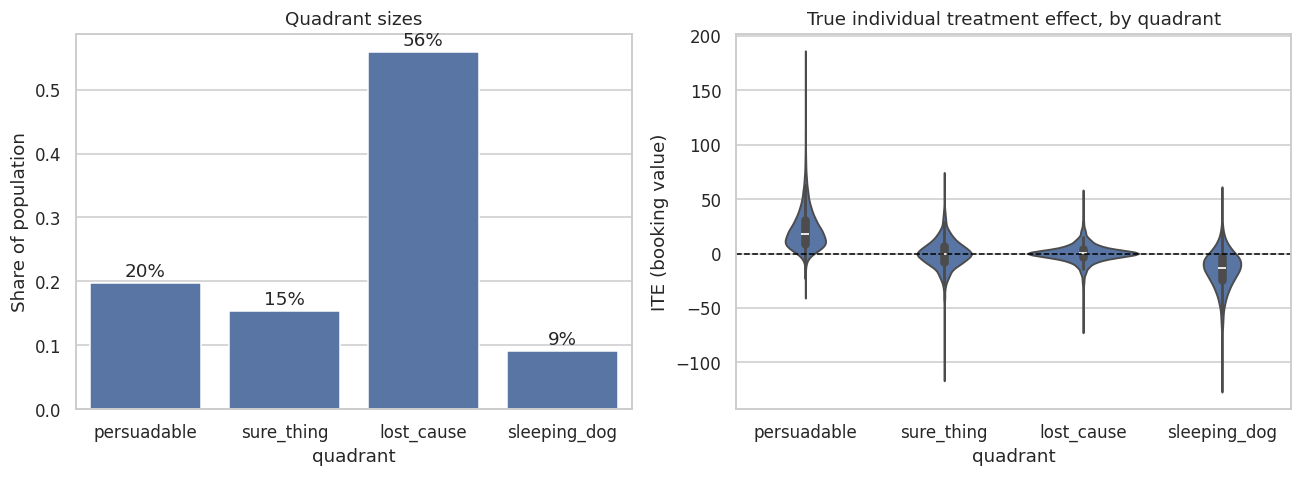

In [4]:
quadrant_order = ["persuadable", "sure_thing", "lost_cause", "sleeping_dog"]
counts = df["quadrant"].value_counts(normalize=True).reindex(quadrant_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=counts.index, y=counts.values, ax=axes[0], order=quadrant_order)
axes[0].set_ylabel("Share of population")
axes[0].set_title("Quadrant sizes")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.01, f"{v:.0%}", ha="center")

sns.violinplot(data=df, x="quadrant", y="ite_true", order=quadrant_order, ax=axes[1], cut=0)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("True individual treatment effect, by quadrant")
axes[1].set_ylabel("ITE (booking value)")

plt.tight_layout()
plt.savefig("../figures/02_quadrants.png", bbox_inches="tight")
plt.show()

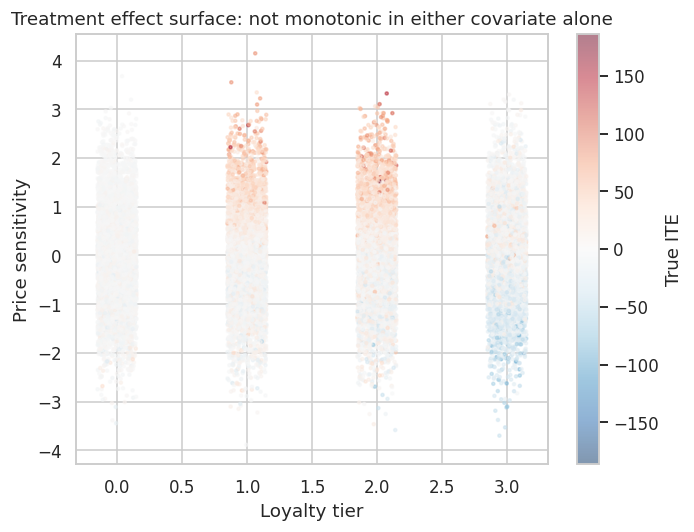

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(
    df["loyalty_tier"] + np.random.uniform(-0.15, 0.15, len(df)),
    df["price_sensitivity"],
    c=df["ite_true"],
    cmap="RdBu_r",
    vmin=-df["ite_true"].abs().max(),
    vmax=df["ite_true"].abs().max(),
    s=4,
    alpha=0.5,
)
plt.colorbar(sc, label="True ITE")
ax.set_xlabel("Loyalty tier")
ax.set_ylabel("Price sensitivity")
ax.set_title("Treatment effect surface: not monotonic in either covariate alone")
plt.tight_layout()
plt.savefig("../figures/03_ite_surface.png", bbox_inches="tight")
plt.show()

## 3. Why this sets up the Day 2 model

Two separate problems, one dataset:

1. **Selection bias** — treatment assignment correlates with covariates that also affect the outcome, so any model trained naively on `treatment -> outcome` inherits that bias. This needs propensity-based debiasing (IPW / doubly robust).
2. **Effect heterogeneity** — a single ATE is not actionable for budget allocation; the model needs to estimate a *conditional* average treatment effect (CATE) per user, and it needs to get the sign right for sleeping dogs, not just the magnitude for persuadables.

Notebook 02 builds a naive S-learner (ignores both problems) as a baseline, and Notebook 03 builds the attention-based, doubly-robust neural model (an extension of Dragonnet, Shi et al. 2019) that addresses both — matching the causal debiasing and neural-architecture requirements in the JD directly.